![FaMAF-UNC](https://drive.google.com/uc?export=download&id=1k4tzcXOoq6TrkDEW_Ox8o4Y4pAHzKHb7
)
> Docentes: **Damián Fernández** y **Leandro Milne**
>> Teórico del 26-03-2021


# Geometría del espacio Euclídeo

La clase pasada definimos el hiperplano generado por $w\in\mathbb{R}^n$ y $b\in\mathbb{R}$ como
$$
    \mathcal{H}_{w,b} = \{ x \in\mathbb{R}^n \mid \langle w, x \rangle = b \}.
$$
Este hiperplano nos separa $\mathbb{R}^n$ en dos semiespacios
\begin{gather*}
    \mathcal{H}^{-}_{w,b} = \{ x \in\mathbb{R}^n \mid \langle w, x \rangle \leq b \},\\
    \mathcal{H}^{+}_{w,b} = \{ x \in\mathbb{R}^n \mid \langle w, x \rangle \geq b \}.
\end{gather*}
Veamos una aplicación de estos conjuntos.


---

#### Ejemplo (Support Vector Machine)

Una conocida técnica de aprendizaje automático (*machine learning*) conocida como máquina de soporte vectorial (SVM por sus siglas en inglés), se basa en encontrar un hiperplano $\mathcal{H}_{w,b}$ para separar datos que corresponden a dos grupos. Los datos pueden ser, por ejemplo, puntos en $x^k\in \mathbb{R}^{24}$ (llamado características) correspondientes a mediciones de consumo de electricidad mensuales durante dos años y los dos grupos a determinar son los usuarios que tienen una conexión ilegal, digamos con $y_k=1$, y los que no, con $y_k=-1$ (llamado rótulos).

Para ello se utiliza un conjunto de entrenamiento $\{(x^1,y_1), \ldots, (x^d,y_d)\}$ para obtener $w\in\mathbb{R}^{24}$ y $b\in\mathbb{R}$ tal que el grupo con conexiones ilegales quede contenido en $\mathcal{H}^{+}_{w,b}$ y el otro en $\mathcal{H}^{-}_{w,b}$. Esto es llamado proceso de aprendizaje y matemáticamente consiste en resolver un problema de minimización, por ejemplo
$$
\mathop{\mathrm{minimizar}}_{(w,b)\in \mathbb{R}^{24}\times \mathbb{R}}\sum_{k=1}^d \max\left\{0, 1 - (\langle w, x^k\rangle - b)y_k\right\},
$$
o
$$
\mathop{\mathrm{minimizar}}_{(w,b)\in \mathbb{R}^{24}\times \mathbb{R}}\sum_{k=1}^d \log\left(1+\exp\bigl(-(\langle w, x^k\rangle - b)y_k\bigr)\right).
$$

Luego, dado cualquier dato $x\in\mathbb{R}^{24}$ de un usuario fuera del conjunto de entrenamiento, evaluamos la función $f:\mathbb{R}^{24} \mapsto \{-1,1\}$ tal que
$$
f(x) = \left\{\begin{array}{rl}
        1 & \textrm{si } \langle w, x\rangle -b \geq 0,\\
        -1& \textrm{si } \langle w, x\rangle -b <0.
        \end{array} \right.
$$
De esta manera la computadora puede darnos una predicción rápida sobre la condición de un usuario en función de sus características.

---


Realizando intersecciones de semiespacios desplazados se obtienen poliedros. Lo que es más, dado un poliedro $\mathcal{G}\subset \mathbb{R}^n$ existen $a^1, \ldots, a^r \in \mathbb{R}^n$ y $b_1, \ldots, b_r \in \mathbb{R}$ tales que
$$
\mathcal{G} = \{ x \in\mathbb{R}^n \mid \langle a^i, x\rangle \leq b_i, \, i=1, \ldots, r\}.
$$

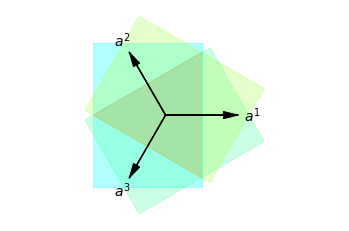

In [ ]:
#@title Poliedro { display-mode: "form" }
n = 3 #@param {type:"slider", min:3, max:10, step:1}
import numpy as np
import matplotlib.pyplot as plt

#n = 5
b = 0.5
th = np.arange(0,2*np.pi,2*np.pi/n)
W = np.array([np.cos(th), np.sin(th)])
P = W.copy()


for i in range(n):
  w = W[:,i]
  wp = np.array([-w[1], w[0]])
  wb = b/np.inner(w, w)*w
  vno = wb + wp
  vne = wb - wp
  vso = -w + wp
  vse = -w - wp
  P[:,i] = np.linalg.solve(np.array([W[:,i-1], W[:,i]]), b*np.ones(2))

  plt.plot([0, w[0]], [0, w[1]], 'k')
  plt.arrow(0, 0, w[0], w[1], head_width=0.1, head_length=0.2, length_includes_head=True, color='k')
  plt.text(1.2*w[0], 1.2*w[1],f'$a^{i+1}$',color='k',fontsize=14, verticalalignment='center',horizontalalignment='center')
  plt.fill([vno[0],vso[0],vse[0],vne[0]], [vno[1],vso[1],vse[1],vne[1]], color=(i/n,1,1-i/n), alpha=0.3)

plt.fill(P[0],P[1], color='r', alpha=0.1)
plt.axis('equal')
plt.axis('off');
plt.savefig('poliedro.pdf')


Otra de las consecuencias de la desigualdad de Cauchy-Schwarz es la siguiente.

>**Corolario (Desigualdad triangular)**
>
>Para cualquier $x,y\in\mathbb{R}^n$ se tiene que
$$
\|x+y\| \leq \|x\| + \|y\|.
$$

**Demostración:**
Como $\langle x, y\rangle \leq | \langle x, y\rangle | \leq \|x\| \|y\|$, entonces
\begin{align*}
    \|x+y\|^2   &= \|x\|^2 + 2 \langle x, y \rangle + \|y\|^2 \\
                &\leq \|x\|^2 + 2\|x\| \|y\| + \|y\|^2 \\
                &= (\|x\| + \|y\|)^2.
\end{align*}
Tomando raíz cuadrada en ambos miembros se obtiene el resultado deseado. $\spadesuit$


Aunque en este curso trabajaremos únicamente con la norma Euclídea, debemos remarcar que existen otras normas, como la norma de la suma $\|x\|_S = |x_1| + |x_2| + \ldots + |x_n|$ o la norma del máximo $\|x\|_M = \max\{|x_1|, |x_2|, \ldots, |x_n|\}$. La interpretación de estas normas está fuera del alcance de este curso. No obstante, toda norma cumple con las siguientes propiedades: dados $x, y\in \mathbb{R}^n$ y $\alpha \in \mathbb{R}$,
1. $\|x\| \geq 0$ con $\|x\|=0$ si y sólo si $x=0$ (positividad),
2. $\|\alpha x\| = |\alpha| \|x\|$ (homogeneidad),
3. $\|x+y\| \leq \|x\| + \|y\|$ (desigualdad triangular).



Con lo visto anteriormente, dados $x,y\in\mathbb{R}^n$ se puede verificar la regla del coseno.

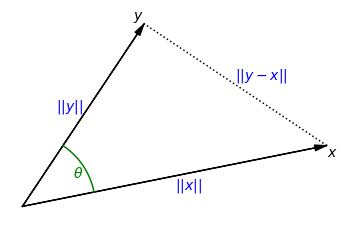

In [ ]:
#@title Regla del coseno
u = 5
x = u*np.array([0.5, 0.1])
y = u*np.array([0.2, 0.3])
w = np.inner(x, y)/np.inner(x, x) * x
z = y - w
# x
plt.plot([0, x[0]], [0, x[1]], 'k')
plt.arrow(0, 0, x[0], x[1], head_width=0.05, head_length=0.1, length_includes_head=True, color='k')
plt.text(x[0], x[1],'$x$',color='k',fontsize=14, verticalalignment='top',horizontalalignment='left')
plt.text(0.5*x[0], 0.5*x[1],'$||x||$',color='b',fontsize=14, verticalalignment='top',horizontalalignment='left')
# y
plt.plot([0, y[0]], [0, y[1]], 'k')
plt.arrow(0, 0, y[0], y[1], head_width=0.05, head_length=0.1, length_includes_head=True, color='k')
plt.text(y[0], y[1],'$y$',color='k',fontsize=14, verticalalignment='bottom',horizontalalignment='right')
plt.text(0.5*y[0], 0.5*y[1],'$||y||$',color='b',fontsize=14, verticalalignment='bottom',horizontalalignment='right')
# y-x
plt.plot([x[0],y[0]], [x[1],y[1]], 'k:')
plt.text(0.5*(x[0]+y[0]), 0.5*(x[1]+y[1]),'$||y-x||$',color='b',fontsize=14, verticalalignment='bottom',horizontalalignment='left')

xx = x/np.linalg.norm(x)
yy = y/np.linalg.norm(y)
rr = 0.6
th1 = np.arccos(xx[0])
th2 = np.arccos(yy[0])
tt = np.linspace(th1, th2, 200)
plt.plot(rr*np.cos(tt), rr*np.sin(tt), 'g')
plt.text(rr*np.cos(tt[100]), rr*np.sin(tt[100]),'$\\theta$',color='g',fontsize=14, verticalalignment='top',horizontalalignment='right')
plt.axis('equal')
plt.axis('off');
#plt.savefig('regla_coseno.pdf')

Note que
\begin{align*}
    \|y-x\|^2 &= \langle y, y\rangle + \langle x, x\rangle - 2 \langle x, y\rangle  \\
            &= \|y\|^2 + \|x\|^2 - 2 \|y\| \|x\| \cos(\theta).
\end{align*}


Una norma en $\mathbb{R}^n$ da origen a la noción de distancia entre dos puntos $x, y\in \mathbb{R}^n$ y viene dada por
$$
\mathrm{d}(x,y) = \|y-x\|.
$$

Las propiedades de una distancia son:
1. $\mathrm{d}(x,y) \geq 0$ con $\mathrm{d}(x,y)=0$ si y sólo si $y=x$ (no negatividad),
2. $\mathrm{d}(x,y) = \mathrm{d}(y,x)$ (simetría),
3. $\mathrm{d}(x,z) \leq \mathrm{d}(x,y) + \mathrm{d}(y,z)$ (desigualdad triangular).
Vale porque
\begin{align*}
\mathrm{d}(x,z) &= \|z-x\| = \|z-y+y-x\|\\
  &\leq \|z-y\| + \|y-x\| \\
  & = \mathrm{d}(y,z) + \mathrm{d}(x,y) \\
  & = \mathrm{d}(x,y) + \mathrm{d}(y,z).
\end{align*}

Es importante aclarar que existen distancias que no están asociadas a normas, pero las mismas no serán abordadas en este curso.



Para finalizar esta sección, introduciremos una operación entre elementos de $\mathbb{R}^n$ asociada a la orientación de vectores. Recuerde primero que dada una matriz $A\in\mathbb{R}^{n \times n}$ su determinante desarrollado a partir de la primera fila se define como
$$
\det(A)=\sum_{j=1}^n (-1)^{j+1} a_{1j} \det(\check{A}_{1j}),
$$
donde $\check{A}_{1j}$ es una matriz obtenida eliminando la fila $1$ y la columna $j$ de $A$.

Recuerde que el determinante tiene las siguientes propiedades:
1. Si $B$ se obtiene de $A$ intercambiando dos filas, entonces $\det(B) = - \det(A)$.
2. Si $B$ se obtiene de $A$ multiplicando una de sus filas por $\alpha$, entonces $\det(B) = \alpha \det(A)$.
3. Si $A$, $B$ y $C$ son iguales salvo en su $j$-ésima fila y la fila $j$ de $C$ es la suma de la fila $j$ de $A$ y $B$, entonces $\det(C) = \det(A) + \det(B)$.
4. Si $A$ es invertible si y sólo si $\det(A)\neq 0$.



Con esto, definimos el producto vectorial (o producto cruz) de los vectores $v^1, v^2, \ldots, v^{n-1} \in \mathbb{R}^n$ como
$$
v^1 \times v^2 \times \ldots \times v^{n-1} = \sum_{j=1}^n (-1)^{j+1} \det(\check{V}_{j}) \, e^j,
$$
donde $V \in \mathbb{R}^{(n-1)\times n}$ es una matriz que tiene como filas a los vectores $v^i$ y $\check{V}_j$ se obtiene eliminando la columna $j$ de $V$.


Note que para cualquier $x\in\mathbb{R}^n$ se tiene
\begin{align*}
\langle v^1 \times v^2 \times \ldots \times v^{n-1}, x \rangle
        &= \sum_{j=1}^n (-1)^{j+1} \det(\check{V}_{j}) \, \langle e^j, x\rangle \\
        &= \sum_{j=1}^n (-1)^{j+1} \det(\check{V}_{j}) \, x_j \\
        &= \det\left(\left[ \begin{array}{cccc}
             x_1 & x_2 & \ldots & x_n  \\
             v^1_1 & v^1_2 & \ldots & v^1_n  \\
             \vdots & \vdots & & \vdots \\
             v^{n-1}_1 & v^{n-1}_2 & \ldots & v^{n-1}_n
        \end{array}\right] \right).
\end{align*}
Por lo tanto, si $w = v^1 \times v^2 \times \ldots \times v^{n-1}$ entonces $w$ es ortogonal a $v^i$ para $i=1, \ldots, n-1$.


Además, de las propiedades del determinante, se deduce que: el signo cambia al permutar dos vectores, o sea
$$
v^1 \times \ldots \times v^i \times \ldots \times v^j \times \ldots \times v^{n-1} = - v^1 \times \ldots \times v^j \times \ldots \times v^i \times \ldots \times v^{n-1},
$$
es lineal en cada argumento, o sea
$$
v^1 \times \ldots \times (\alpha x + \beta y) \times \ldots  \times v^{n-1} = \alpha v^1 \times \ldots \times x \times \ldots  \times v^{n-1} + \beta v^1 \times \ldots \times y \times \ldots  \times v^{n-1},
$$
y $v^1 \times v^2 \times \ldots \times v^{n-1}$ es cero si $v^1, v^2, \ldots, v^{n-1}$ son linealmente dependientes.


Veamos cómo interpretar el producto vectorial en $\mathbb{R}^3$. Considere $x,y\in\mathbb{R}^3$, entonces
\begin{align*}
    z   &= x \times y \\
        &= \det\left(\left[ \begin{array}{cc}
             x_2 & x_3 \\
             y_2 & y_3
             \end{array}\right] \right) e^1
        - \det\left(\left[ \begin{array}{cc}
             x_1 & x_3 \\
             y_1 & y_3
             \end{array}\right] \right) e^2
        + \det\left(\left[ \begin{array}{cc}
             x_1 & x_2 \\
             y_1 & y_2
             \end{array}\right] \right) e^3 \\
        &= (x_2 y_3 - x_3 y_2, \, x_3 y_1 - x_1 y_3,\,  x_1 y_2 - x_2 y_1).
\end{align*}


La regla regla de la mano derecha es una regla práctica para visualizar la orientación de $z$ en el espacio.
<figure>
<center>
<img src='https://drive.google.com/uc?export=download&id=1p9kjLshWLBCwwqm9UNaIN6W1xYwuCfmL' width="300"/>
<figcaption>Regla de la mano derecha.</figcaption></center>
</figure>

Se puede verificar fácilmente que si $e^1, e^2, e^3\in\mathbb{R}^3$, vale que
$$
e^1 \times e^2 = e^3, \qquad e^2 \times e^3 = e^1, \qquad e^3 \times e^1 = e^2.
$$

Para obtener la longitud de $x \times y$, note que
\begin{align*}
    \| x\times y\|^2 &= (x_2 y_3 - x_3 y_2)^2 + (x_3 y_1 - x_1 y_3)^2 + (x_1 y_2 - x_2 y_1)^2 \\
        &= (x_1^2 + x_2^2 + x_3^2)(y_1^2 + y_2^2 + y_3^2) - (x_1 y_1 + x_2 y_2 + x_3 y_3)^2 \\
        &= \|x\|^2 \|y\|^2 - \langle x, y \rangle ^2 \\
        &= \|x\|^2 \|y\|^2 - \|x\|^2 \|y\|^2 \cos^2(\theta) \\
        &= \|x\|^2 \|y\|^2 \operatorname{sen}^2(\theta),
\end{align*}
donde $\theta$ es el ángulo que separa $x$ e $y$. Por lo tanto $\| x\times y\| = \|x\| \|y\| \operatorname{sen}(\theta)$.


Note que si tomamos $x$ como la base del paralelogramo formado por $x$ e $y$, entonces la longitud de su base es $\|x\|$ y su altura es $\|y\| \operatorname{sen}(\theta)$. Luego, la longitud de $x \times y$ es igual a la superficie del paralelogramo formado por los vectores $x$ e $y$.


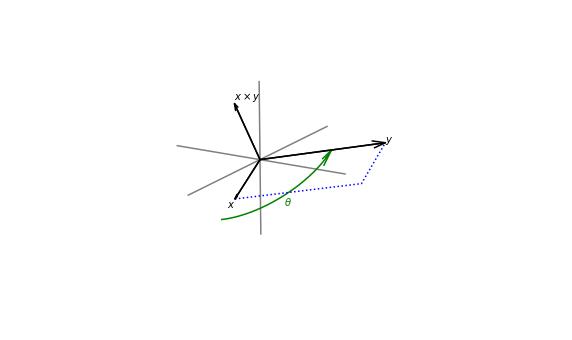

In [ ]:
#@title Producto vectorial { form-width: "30%", display-mode: "form" }
x1 = 0.6 #@param {type:"slider", min:-2, max:2, step:0.2}
x2 = 0.2 #@param {type:"slider", min:-2, max:2, step:0.2}
x3 = -0.2 #@param {type:"slider", min:-2, max:2, step:0.2}

import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits import mplot3d

plt.figure(figsize=(10,6))
ax = plt.axes(projection='3d')
x = np.array([x1, x2, x3])
#x = np.array([2, 0.1, -0.2])
y = np.array([0.2, 1.6, 0.6])
# ejes
vmin = np.minimum(-1, np.min(x))
vmax = np.maximum(1, np.max(x))
ax.plot3D([vmin,vmax], [0,0], [0,0], color=(0.5,0.5,0.5))
ax.plot3D([0,0], [vmin,vmax], [0,0], color=(0.5,0.5,0.5))
ax.plot3D([0,0], [0,0], [vmin,vmax], color=(0.5,0.5,0.5))
# x
ax.quiver(0, 0, 0, x[0], x[1], x[2], color='k', arrow_length_ratio=0.1)
ax.plot3D([0,x[0]], [0,x[1]], [0,x[2]], 'k')
ax.text3D(x[0], x[1], x[2],'$x$', verticalalignment='top', horizontalalignment='right')
# y
ax.quiver(0, 0, 0, y[0], y[1], y[2], color='k', arrow_length_ratio=0.1)
ax.plot3D([0,y[0]], [0,y[1]], [0,y[2]], 'k')
ax.text3D(y[0], y[1], y[2],'$y$')
# z
z = np.array([x[1]*y[2] - x[2]*y[1], x[2]*y[0] - x[2]*y[2], x[0]*y[1] - x[1]*y[0]])
ax.quiver(0, 0, 0, z[0], z[1], z[2], color='k', arrow_length_ratio=0.1)
ax.plot3D([0,z[0]], [0,z[1]], [0,z[2]], 'k')
ax.text3D(z[0], z[1], z[2],r'$x \times y$', verticalalignment='bottom', horizontalalignment='left')
# angulo
xx = x/np.linalg.norm(x)
yy = y/np.linalg.norm(y)
th = np.linspace(0, np.pi/2, 100)
ctheta = np.outer(xx, np.cos(th)) + np.outer(yy, np.sin(th))
ax.plot3D(ctheta[0], ctheta[1], ctheta[2], color='g')
ax.quiver(ctheta[0,-10], ctheta[1,-10], ctheta[2,-10], ctheta[0,-1]-ctheta[0,-10], ctheta[1,-1]-ctheta[1,-10], ctheta[2,-1]-ctheta[2,-10], color='g', arrow_length_ratio=1.5)
ax.text3D(ctheta[0,50], ctheta[1,50], ctheta[2,50], r'$\theta$', color='g', verticalalignment='top', horizontalalignment='left')
# suma
s = x+y
ax.plot3D([x[0], s[0], y[0]], [x[1], s[1], y[1]], [x[2], s[2], y[2]], 'b:')

ax.view_init(30, 30)
ax.axis('off');
#plt.savefig('producto_cruz.pdf')

Más aún, dado $z\in\mathbb{R}^3$ tenemos que $|\langle x \times y, z \rangle| = \|x \times y\| \|z\| \cos(\varphi)$, donde $\varphi$ es el ángulo entre $z$ y $x \times y$. Note que si miramos el paralelepípedo formado por $x$, $y$, $z$ considerando como base el paralelogramo formado por $x$ e $y$, tendremos que la superficie de su base es $\|x \times y\|$ y su altura es $\|z\| \cos(\varphi)$.


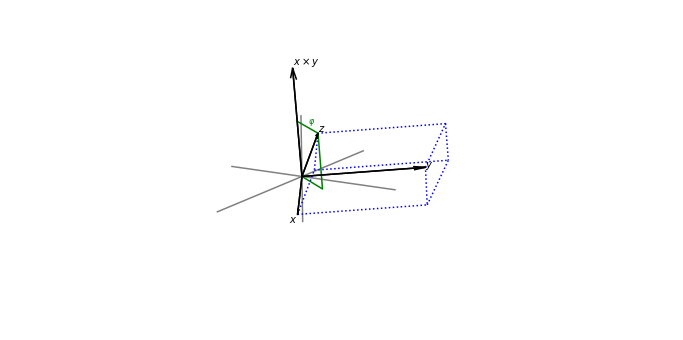

In [ ]:
#@title Paralelepípedo { form-width: "30%", display-mode: "form" }
x1 = 1.3 #@param {type:"slider", min:-1.5, max:1.5, step:0.1}
x2 = 1.1 #@param {type:"slider", min:-1.5, max:1.5, step:0.1}
x3 = 0.2 #@param {type:"slider", min:-1.5, max:1.5, step:0.1}

import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits import mplot3d

plt.figure(figsize=(12,6))
ax = plt.axes(projection='3d')
x = np.array([x1, x2, x3])
#x = np.array([0.9, 1.3, 0.1])
y = np.array([-0.5, 1.3, 0.2])
z = np.array([0.3, 0.5, 1.2])
# ejes
vmin = np.minimum(-1, np.min(x))
vmax = np.maximum(1, np.max(x))
ax.plot3D([vmin,vmax], [0,0], [0,0], color=(0.5,0.5,0.5))
ax.plot3D([0,0], [vmin,vmax], [0,0], color=(0.5,0.5,0.5))
ax.plot3D([0,0], [0,0], [vmin,vmax], color=(0.5,0.5,0.5))
# x
ax.quiver(0, 0, 0, x[0], x[1], x[2], color='k', arrow_length_ratio=0.1)
ax.plot3D([0,x[0]], [0,x[1]], [0,x[2]], 'k')
ax.text3D(x[0], x[1], x[2],'$x$', verticalalignment='top', horizontalalignment='right')
# y
ax.quiver(0, 0, 0, y[0], y[1], y[2], color='k', arrow_length_ratio=0.1)
ax.plot3D([0,y[0]], [0,y[1]], [0,y[2]], 'k')
ax.text3D(y[0], y[1], y[2],'$y$')
# z
ax.quiver(0, 0, 0, z[0], z[1], z[2], color='k', arrow_length_ratio=0.1)
ax.plot3D([0,z[0]], [0,z[1]], [0,z[2]], 'k')
ax.text3D(z[0], z[1], z[2],'$z$', verticalalignment='bottom', horizontalalignment='left')
# w = x \times y
w = np.array([x[1]*y[2] - x[2]*y[1], x[2]*y[0] - x[2]*y[2], x[0]*y[1] - x[1]*y[0]])
ax.quiver(0, 0, 0, w[0], w[1], w[2], color='k', arrow_length_ratio=0.1)
ax.plot3D([0,w[0]], [0,w[1]], [0,w[2]], 'k')
ax.text3D(w[0], w[1], w[2],r'$x \times y$', verticalalignment='bottom', horizontalalignment='left')
# suma
sxy = x+y
ax.plot3D([x[0], sxy[0], y[0]], [x[1], sxy[1], y[1]], [x[2], sxy[2], y[2]], 'b:')
sxz = x+z
ax.plot3D([x[0], sxz[0], z[0]], [x[1], sxz[1], z[1]], [x[2], sxz[2], z[2]], 'b:')
syz = y+z
ax.plot3D([y[0], syz[0], z[0]], [y[1], syz[1], z[1]], [y[2], syz[2], z[2]], 'b:')
sxyz = x+y+z
ax.plot3D([sxy[0], sxyz[0]], [sxy[1], sxyz[1]], [sxy[2], sxyz[2]], 'b:')
ax.plot3D([sxz[0], sxyz[0]], [sxz[1], sxyz[1]], [sxz[2], sxyz[2]], 'b:')
ax.plot3D([syz[0], sxyz[0]], [syz[1], sxyz[1]], [syz[2], sxyz[2]], 'b:')
# proyecciones
pz_w = np.inner(z,w)/np.inner(w,w)*w
pz_xy = z - pz_w
ax.plot3D([0, pz_xy[0], z[0]], [0, pz_xy[1], z[1]], [0, pz_xy[2], z[2]], 'g')
ax.plot3D([pz_w[0], z[0]], [pz_w[1], z[1]], [pz_w[2], z[2]], 'g')
ax.text3D(0.5*(pz_w[0]+z[0]), 0.5*(pz_w[1]+z[1]), 0.5*(pz_w[2]+z[2]),r'$\varphi$', color='g', fontsize=8, verticalalignment='bottom', horizontalalignment='left')


ax.view_init(30, 30)
ax.axis('off');
#plt.savefig('paralelepipedo.pgf')

Concluyendo que
$$
|\langle x \times y, z \rangle|
        = \left|\det\left(\left[ \begin{array}{ccc}
             z_1 & z_2 & z_3  \\
             x_1 & x_2 & x_3  \\
             y_1 & y_2 & y_3
        \end{array}\right] \right) \right|
                = \left|\det\left(\left[ \begin{array}{ccc}
             x_1 & x_2 & x_3  \\
             y_1 & y_2 & y_3 \\
             z_1 & z_2 & z_3
        \end{array}\right] \right) \right|,
$$
es el volumen del paralelepípedo formado por los vectores $x$, $y$ y $z$.


In [ ]:
#@title No olvide cómo giran las tuercas { display-mode: "form" }
%%html
<iframe src="https://giphy.com/embed/xT0xez0JE0BFpQsx68" width="480" height="360" frameBorder="0" class="giphy-embed" allowFullScreen></iframe><p><a href="https://giphy.com/gifs/animation-happy-cute-xT0xez0JE0BFpQsx68">via GIPHY</a></p>